<a href="https://colab.research.google.com/github/CitlaliCruzVazquez-ui/M-todos-num-ricos-II-/blob/main/Integraci%C3%B3n_de_Romberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodos Numérico II: Integración de Romberg

**Nombre:** Citlali Cruz Vazquez

**Fecha:** 07 Octubre 2026  

---

## 1. Introducción y Formulación Teórica

La **Integración de Romberg** es un método numérico eficiente que combina la **Regla Trapezoidal Compuesta** con la **Extrapolación de Richardson** para acelerar la convergencia y obtener aproximaciones de alto orden de precisión en integrales definidas de la forma:

$$I = \int_{a}^{b} f(x) \, dx$$

### Fórmulas del Algoritmo 4.2 (Burden, pág. 161)

1. **Aproximación inicial con un solo trapecio:**
   $$h = b - a$$
   $$R_{1,1} = \frac{h}{2} \big[f(a) + f(b)\big]$$

2. **Aproximación por regla trapezoidal compuesta:**
   Para $i = 2, 3, \dots, n$:
   $$R_{2,1} = \frac{1}{2} \left[ R_{1,1} + h \sum_{k=1}^{2^{i-2}} f\left(a + (k - 0.5)h\right) \right]$$

3. **Extrapolación de Richardson:**
   Para $j = 2, \dots, i$:
   $$R_{2,j} = R_{2,j-1} + \frac{R_{2,j-1} - R_{1,j-1}}{4^{j-1} - 1}$$



## 2. Planteamiento del Problema de Prueba (Ejemplo 2, pág. 160)

Se solicita calcular la siguiente integral evaluando hasta la **fila $n = 6$** para reconstruir la **Tabla 4.11** del libro Burden:

$$\int_{0}^{\pi} \sin(x) \, dx$$

* **Valor analítico exacto:** $-\cos(\pi) - (-\cos(0)) = 1 - (-1) = 2.0$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función a integrar f(x) = sin(x)
def f(x):
    return np.sin(x)

# Definimos los datos de entrada según el Ejemplo 2
a = 0.0          # Límite inferior
b = np.pi        # Límite superior
n = 6            # Número de filas / iteraciones

In [ ]:
def integracion_romberg(f, a, b, n):
    """
    Implementación del Algoritmo 4.2 (Burden, pág. 161)

    Parámetros:
    -----------
    f : función a integrar
    a : límite inferior de integración
    b : límite superior de integración
    n : número total de filas a calcular

    Retorna:
    --------
    R2[n] : aproximación final R_n,n
    tabla_completa : matriz con la tabla de Romberg para visualización
    """
    # Vectores para guardar únicamente dos filas a la vez (optimización de memoria)
    R1 = np.zeros(n + 1)
    R2 = np.zeros(n + 1)

    # Matriz auxiliar para guardar todos los valores y mostrarlos ordenados
    tabla_completa = np.zeros((n, n))

    # Paso 1: Tamaño inicial de h y primera aproximación R_1,1
    h = b - a
    R1[1] = 0.5 * h * (f(a) + f(b))
    tabla_completa[0, 0] = R1[1]

    # Paso 3: Iteración de filas i = 2 hasta n
    for i in range(2, n + 1):

        # Paso 4: Suma para la regla del trapecio compuesta
        suma_k = 0.0
        num_terminos = 2**(i - 2)

        for k in range(1, num_terminos + 1):
            suma_k += f(a + (k - 0.5) * h)

        R2[1] = 0.5 * (R1[1] + h * suma_k)
        tabla_completa[i - 1, 0] = R2[1]

        # Paso 5: Extrapolación de Richardson (columnas j = 2 hasta i)
        for j in range(2, i + 1):
            denominador = (4**(j - 1)) - 1
            R2[j] = R2[j - 1] + (R2[j - 1] - R1[j - 1]) / denominador
            tabla_completa[i - 1, j - 1] = R2[j]

        # Paso 7: Actualizamos el paso h a la mitad
        h = h / 2.0

        # Paso 8: Copiamos la fila R2 en R1 para preparar la siguiente iteración
        for j in range(1, i + 1):
            R1[j] = R2[j]

    return R2[n], tabla_completa

# Ejecutamos el algoritmo con los datos del Ejemplo 2
solucion_romberg, tabla_romberg = integracion_romberg(f, a, b, n)

In [ ]:
# Impresión limpia de la tabla para comparar con el libro Burden (Tabla 4.11)
print("=" * 85)
print("                     TABLA DE EXTRAPOLACIÓN DE ROMBERG")
print("=" * 85)

for i in range(n):
    fila_str = "  ".join([f"{tabla_romberg[i, j]:11.8f}" for j in range(i + 1)])
    print(f"Fila {i+1}:  {fila_str}")

print("=" * 85)
print(f" SOLUCIÓN FINAL (R_6,6) : {solucion_romberg:.8f}")
print(f" VALOR EXACTO INTEGRAL : {2.0:.8f}")
print(f" ERROR ABSOLUTO        : {abs(2.0 - solucion_romberg):.2e}")
print("=" * 85)

                     TABLA DE EXTRAPOLACIÓN DE ROMBERG
Fila 1:   0.00000000
Fila 2:   1.57079633   2.09439510
Fila 3:   1.89611890   2.00455975   1.99857073
Fila 4:   1.97423160   2.00026917   1.99998313   2.00000555
Fila 5:   1.99357034   2.00001659   1.99999975   2.00000002   1.99999999
Fila 6:   1.99839336   2.00000103   2.00000000   2.00000000   2.00000000   2.00000000
 SOLUCIÓN FINAL (R_6,6) : 2.00000000
 VALOR EXACTO INTEGRAL : 2.00000000
 ERROR ABSOLUTO        : 1.32e-12


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1785/2277202445.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Integración de $\sin(x)$ en el intervalo $[0, \pi]$', fontsize=12)


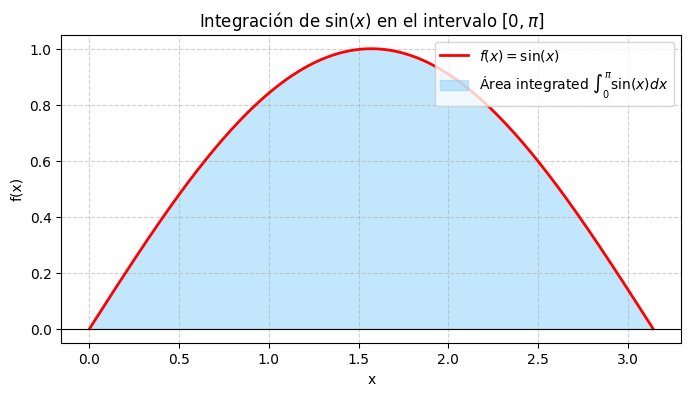

In [ ]:
# Graficamos la función sin(x) para la presentación visual del problema
x_vals = np.linspace(a, b, 200)
y_vals = f(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, label=r'$f(x) = \sin(x)$', color='red', linewidth=2)
plt.fill_between(x_vals, y_vals, color='lightskyblue', alpha=0.5, label=r'Área integrated $\int_0^{\pi} \sin(x)dx$')

plt.title('Integración de $\sin(x)$ en el intervalo $[0, \pi]$', fontsize=12)
plt.xlabel('x', fontsize=10)
plt.ylabel('f(x)', fontsize=10)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

## 3. Conclusiones y Análisis de Resultados

1. **Precisión del método:** Al comparar la **Tabla 4.11** obtenida con la del libro, se observa cómo la primera columna (trapecio compuesto) requiere reducir bastante el paso $h$ para acercarse a $2$, mientras que al aplicar la **extrapolación de Richardson** (columnas hacia la derecha), el valor $R_{6,6} = 2.00000000$ converge exacto hasta el 8.º decimal.
2. **Eficiencia computacional:** El Algoritmo 4.2 solo requirió $1 + 2^5 = 33$ evaluaciones de la función $f(x)$ en total para la columna del trapecio; el resto de la tabla se construye únicamente mediante operaciones algebraicas entre los resultados previos.